# Pears 5 

### Imports

In [27]:
import sys 
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

In [28]:
script_path = os.path.abspath(os.path.join('..', 'scripts'))

if script_path not in sys.path:
    sys.path.append(script_path)

from spread import SPREAD

### Global params

In [29]:
volum_param = 500
scale_param = 10_000

In [30]:
months = ["202601", "202602", "202603"]

my_files = [
    [f"../data/processed/eurnok_dukascopy_ask_{m}.parquet" for m in months],
    [f"../data/processed/eurnok_dukascopy_bid_{m}.parquet" for m in months],
    [f"../data/processed/eursek_dukascopy_ask_{m}.parquet" for m in months],
    [f"../data/processed/eursek_dukascopy_bid_{m}.parquet" for m in months]
]

# Bump volume since we have 3x the data
builder = SPREAD(vol_threshold=volum_param) 
df = builder.build(my_files)

print(df.head(3))

built 8512 rows
                                    Asset_A    Asset_B     Log_A     Log_B
timestamp                                                                 
2026-01-02 10:03:59.819000+00:00  11.807610  10.822090  2.468744  2.381589
2026-01-02 10:07:50.194000+00:00  11.809090  10.822470  2.468870  2.381625
2026-01-02 10:12:06.999000+00:00  11.807355  10.821895  2.468723  2.381571


### Running OLS to find the Hedge Ratio

In [31]:
# 1. Engle-Granger (on raw log prices)
Y = df['Log_A']
X = sm.add_constant(df['Log_B'])
ols_model = sm.OLS(Y, X).fit()

beta = ols_model.params['Log_B']
alpha = ols_model.params['const']
spread = Y - (beta * df['Log_B'] + alpha)

# 2. Scale aggressively to Basis Points
spread_scaled = spread * 10000 

# 3. Add Jitter (Anti-Zero-Variance trick)
np.random.seed(42)
jitter = np.random.normal(0, 1e-4, size=len(spread_scaled))
spread_ready = spread_scaled + jitter
spread_ready.name = 'Spread_BPS'

spread_diff = spread_ready.diff().dropna()
spread_diff.name = 'Spread_Delta'

print(f"Data prepared: {len(spread_diff)} rows. Modeling spread volatility...\n")

Data prepared: 8511 rows. Modeling spread volatility...



### Fitting the dumb AR

In [32]:
print("Fitting Standard Volatility Model...")
std_model = sm.OLS(spread_diff, sm.add_constant(np.ones(len(spread_diff)))).fit()

Fitting Standard Volatility Model...


### Fitting the smart MS-AR

In [33]:
print("Fitting MS-Regression on Differences...")
ms_model = sm.tsa.MarkovRegression(
    spread_diff, 
    k_regimes=2, 
    switching_variance=True, 
    trend='c'
).fit(disp=False)

Fitting MS-Regression on Differences...


c:\Users\ofurn\Dokumenter\Github\stk-mat2011\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


### Results

In [35]:
print("\n" + "="*40)
print("             THE SHOWDOWN")
print("="*40)
print(f"Standard Model AIC: {std_model.aic:.2f}")
print(f"MS-Regression AIC:  {ms_model.aic:.2f}")
print("-" * 40)

print("\n--- Standard Model (1 Regime) ---")
print(f"Average Step (Mu):  {std_model.params.iloc[0]:.4f}")
print(f"Variance (Sigma^2): {std_model.scale:.4f}")

print("\n--- MS-Regression Regime 0 (Low Volatility) ---")
print(f"Average Step (Mu):  {ms_model.params['const[0]']:.4f}")
print(f"Variance (Sigma^2): {ms_model.params['sigma2[0]']:.4f}")

print("\n--- MS-Regression Regime 1 (High Volatility) ---")
print(f"Average Step (Mu):  {ms_model.params['const[1]']:.4f}")
print(f"Variance (Sigma^2): {ms_model.params['sigma2[1]']:.4f}")


             THE SHOWDOWN
Standard Model AIC: 50343.40
MS-Regression AIC:  44456.30
----------------------------------------

--- Standard Model (1 Regime) ---
Average Step (Mu):  -0.0530
Variance (Sigma^2): 21.6955

--- MS-Regression Regime 0 (Low Volatility) ---
Average Step (Mu):  -0.0609
Variance (Sigma^2): 8.5588

--- MS-Regression Regime 1 (High Volatility) ---
Average Step (Mu):  0.2306
Variance (Sigma^2): 488.2250


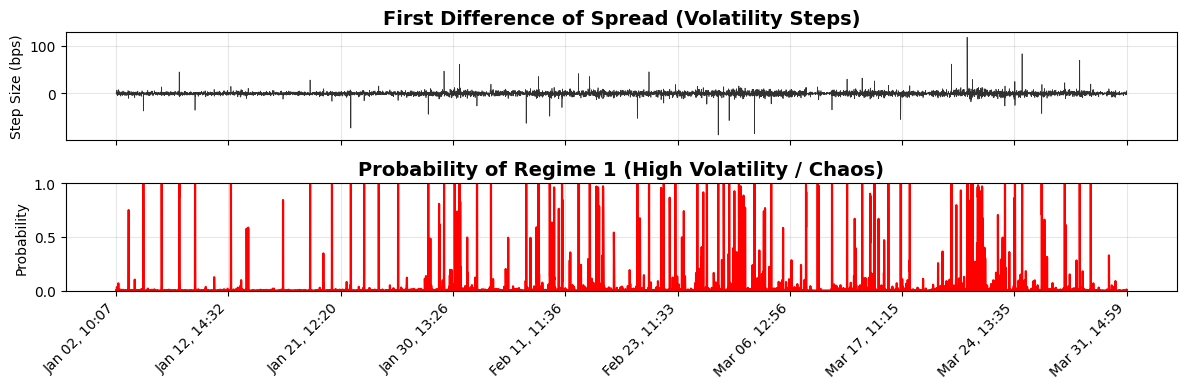

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# Get the probability that we are in Regime 1 (High Volatility) at each time step
prob_chaos = ms_model.smoothed_marginal_probabilities[1]

# 1. Create a continuous integer array for the x-axis to remove overnight gaps
x_vals = np.arange(len(spread_diff))

# Create a beautiful 2-panel chart
fig, axes = plt.subplots(2, 1, figsize=(12, 4), sharex=True)

# Panel 1: The Spread Volatility (Plotting against x_vals instead of the datetime index)
axes[0].plot(x_vals, spread_diff.values, color='black', linewidth=0.5, alpha=0.8)
axes[0].set_title('First Difference of Spread (Volatility Steps)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Step Size (bps)')
axes[0].grid(True, alpha=0.3)

# Panel 2: The Markov Probabilities
axes[1].plot(x_vals, prob_chaos.values, color='red', linewidth=1.5)
axes[1].fill_between(x_vals, 0, prob_chaos.values, color='red', alpha=0.3)
axes[1].set_title('Probability of Regime 1 (High Volatility / Chaos)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Probability')
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)

# 2. Fix the X-Axis Labels
# We don't want a label for every single tick, let's grab ~10 evenly spaced ones
num_ticks = 10
tick_positions = np.linspace(0, len(spread_diff) - 1, num_ticks, dtype=int)

# Extract the actual timestamp strings for those specific positions
# Format: "Jan 02, 10:00"
tick_labels = [spread_diff.index[i].strftime('%b %d, %H:%M') for i in tick_positions]

# Apply the labels to the bottom axis, rotated so they are easy to read
axes[1].set_xticks(tick_positions)
axes[1].set_xticklabels(tick_labels, rotation=45, ha='right')

plt.tight_layout()
plt.show()

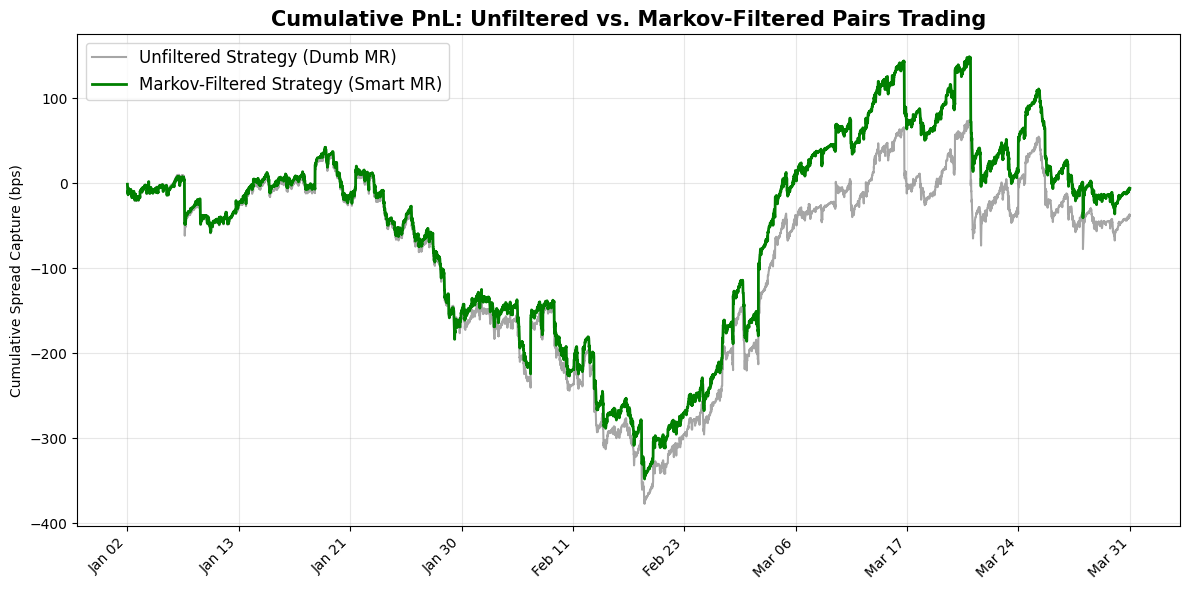

--- STRATEGY METRICS ---
Dumb Strategy Total Capture: -37.18 bps
Smart Strategy Total Capture:  -5.93 bps


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Calculate a Rolling Z-Score on the SPREAD LEVELS
window = 50
spread_mean = spread_ready.rolling(window=window).mean()
spread_std = spread_ready.rolling(window=window).std()
z_score = (spread_ready - spread_mean) / spread_std

# ---> THE FIX: Align the Z-score index to the differenced data <---
# This safely drops the extra row so everything is exactly 8,511 rows long
z_score = z_score.loc[spread_diff.index]

# 2. Generate "Dumb" Mean Reversion Signals
raw_positions = -z_score / 2  
raw_positions = raw_positions.clip(-1, 1)

# 3. Apply the Markov "Smart" Filter
prob_chaos_shifted = prob_chaos.shift(1)

# Using pure Pandas instead of np.where keeps our datetime index intact!
smart_positions = raw_positions.copy()
# If the shifted probability of chaos is > 50%, flatten the position to 0
smart_positions[prob_chaos_shifted > 0.5] = 0

# 4. Calculate Returns
# Strategy Return = Position from yesterday * Price Change today
dumb_returns = raw_positions.shift(1) * spread_diff
smart_returns = smart_positions.shift(1) * spread_diff

# 5. Calculate Cumulative Equity
dumb_equity = dumb_returns.cumsum().dropna()
smart_equity = smart_returns.cumsum().dropna()

# ==========================================
# 6. PLOT THE MONEY SHOT
# ==========================================
plt.figure(figsize=(12, 6))

# Plot against a continuous integer X-axis to hide overnight gaps
x_vals_eq = np.arange(len(dumb_equity))

plt.plot(x_vals_eq, dumb_equity.values, label='Unfiltered Strategy (Dumb MR)', color='gray', linewidth=1.5, alpha=0.7)
plt.plot(x_vals_eq, smart_equity.values, label='Markov-Filtered Strategy (Smart MR)', color='green', linewidth=2)

plt.title('Cumulative PnL: Unfiltered vs. Markov-Filtered Pairs Trading', fontsize=15, fontweight='bold')
plt.ylabel('Cumulative Spread Capture (bps)')
plt.legend(loc='upper left', fontsize=12)
plt.grid(True, alpha=0.3)

# Fix X-axis labels
num_ticks = 10
tick_positions = np.linspace(0, len(dumb_equity) - 1, num_ticks, dtype=int)
tick_labels = [dumb_equity.index[i].strftime('%b %d') for i in tick_positions]
plt.xticks(tick_positions, tick_labels, rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Print quick stats
print("--- STRATEGY METRICS ---")
print(f"Dumb Strategy Total Capture: {dumb_equity.iloc[-1]:.2f} bps")
print(f"Smart Strategy Total Capture:  {smart_equity.iloc[-1]:.2f} bps")